In [1]:
remotes::install_github("Yuanhao-Tang/Modsite")

Skipping 11 packages not available: ggplot2, rtracklayer, S4Vectors, IRanges, GenomeInfoDb, GenomicRanges, GenomicFeatures, AnnotationDbi, tidyr, dplyr, data.table



── R CMD build ─────────────────────────────────────────────────────────────────
* checking for file ‘/tmp/Rtmpy6Ip0p/remotes7ccb47125387/Yuanhao-Tang-Modsite-562d81d/DESCRIPTION’ ... OK
* preparing ‘modsite’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘modsite_0.1.0.tar.gz’



In [3]:
library(modsite)

In [1]:
devtools::load_all("/home/tangyh/script/Modsite")

ℹ Loading modsite
Warning message:
“package ‘testthat’ was built under R version 4.4.3”


In [2]:
base_dir <- "/data_new/RNA_modi/puseq/BN0045"

files <- list.files(
  path = base_dir,
  pattern = "^genome\\.sites\\.tsv$",
  recursive = TRUE,
  full.names = TRUE
)

files <- normalizePath(files, winslash = "/", mustWork = FALSE)

sample_files <- files[!grepl("NC", files)]
conditions <- c("ctrl", "ctrl", "ctrl", "ctrl", "ctrl", "ctrl","ctrl", "ctrl", "ctrl", "ctrl", 
                "ctrl", "ctrl","ctrl", "ctrl", "ctrl", "ctrl", "ctrl", "ctrl","ctrl", "ctrl", 
                "case", "case", "case","case", "case", "case","case", "case", "case", "case",
                "case", "case", "case","case", "case", "case","case", "case", "case")


In [3]:
m <- new_merger(
  sample_files        = sample_files,
  condition           = conditions,
  modification_method = "PUMseq",
  min_modification_rate = 0.05,
  min_depth           = 10L,
  group_missing_threshold = 0.5,
  group_filter_strategy = "any"
)

In [4]:
merged_df <- merge_samples(m)

[1/39] Loading sample: DY-11-24

[2/39] Loading sample: DY-11-25

[3/39] Loading sample: DY-11-26

[4/39] Loading sample: DY-13-PU-21

[5/39] Loading sample: DY-13-PU-23

[6/39] Loading sample: DY-13-PU-27

[7/39] Loading sample: DY-13-PU-28

[8/39] Loading sample: DY-13-PU-29

[9/39] Loading sample: DY-13-PU-5

[10/39] Loading sample: DY-13-PU-8

[11/39] Loading sample: DY-13-PU-9

[12/39] Loading sample: DY-9-PU-15

[13/39] Loading sample: DY-9-PU-2

[14/39] Loading sample: DYR0108-PU10

[15/39] Loading sample: DYR0108-PU11

[16/39] Loading sample: DYR0108-PU12

[17/39] Loading sample: DYR0108-PU17

[18/39] Loading sample: DYR0108-PU31

[19/39] Loading sample: DYR0108-PU32

[20/39] Loading sample: DYR0108-PU4

[21/39] Loading sample: DYR0108-PU7

[22/39] Loading sample: F1-ZJ33

[23/39] Loading sample: F1-ZJ34

[24/39] Loading sample: F1-ZJ35

[25/39] Loading sample: F1-ZJ36

[26/39] Loading sample: F1-ZJ37

[27/39] Loading sample: F1-ZJ38

[28/39] Loading sample: F1-ZJ39

[29/39] Lo

In [6]:
filter_samples(m, max_missing_rate = 0.8)

Checking sample missing-rate (threshold: 0.80) ...

  [drop] DY-13-PU-27  missing-rate = 99.6%

  [drop] S2-ZJ6  missing-rate = 87.7%

  Removed 2 sample(s); 37 sample(s) remain.



In [7]:
m$merged_data

chrom,pos,ref,strand,motif,DY-11-24,depth_DY-11-24,DY-11-25,depth_DY-11-25,DY-11-26,⋯,S2-ZJ16,depth_S2-ZJ16,S2-ZJ18,depth_S2-ZJ18,S2-ZJ20,depth_S2-ZJ20,S2-ZJ22,depth_S2-ZJ22,S2-ZJ30,depth_S2-ZJ30
<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>,<dbl>,<int>
1,135040,T,+,AATGA,0.00000000,258,0.3478261,23,0.00000000,⋯,0.00000000,10,NA,0,0.00000000,68,0.15384615,27,NA,0
1,136586,T,+,GGTGT,NA,43,NA,0,NA,⋯,NA,0,NA,0,0.15094340,54,NA,0,0.14285714,14
1,136768,T,+,CGTGG,NA,49,NA,0,NA,⋯,NA,0,NA,0,0.05172414,66,NA,0,NA,0
1,630727,T,-,AGTAA,0.05882353,17,NA,0,0.10000000,⋯,0.06451613,32,NA,0,0.06666667,45,NA,0,0.06896552,30
1,631857,T,-,ACTCC,NA,10,NA,0,NA,⋯,NA,0,NA,0,0.07692308,13,NA,0,0.00000000,22
1,632693,T,-,GATAT,0.00000000,175,1.0000000,263,0.00000000,⋯,0.00000000,101,0,84,1.00000000,391,0.00000000,29,0.33333333,854
1,632695,T,-,TATTA,0.00000000,175,0.0000000,263,0.00000000,⋯,0.00000000,101,0,81,0.50000000,391,0.00000000,29,0.66666667,854
1,632696,T,-,ATTAG,0.00000000,175,0.0000000,264,0.00000000,⋯,0.00000000,101,0,82,0.00000000,391,0.00000000,29,1.00000000,854
1,632881,T,-,CCTTT,0.07352941,68,NA,0,0.09090909,⋯,NA,0,NA,0,0.14705882,34,0.05882353,17,0.00000000,60


In [8]:
flip_strand <- function(x) {
  x <- as.character(x)
  out <- x
  out[x == "+"] <- "-"
  out[x == "-"] <- "+"
  out
}

m$merged_data$strand <- flip_strand(m$merged_data$strand)


In [13]:
save_merged(m, "/home/tangyh/script/Modsite/modsite.Rcheck/merged_annotated.tsv")
save(m, file = "/home/tangyh/script/Modsite/modsite.Rcheck/m.RData")
load("/home/tangyh/script/Modsite/modsite.Rcheck/m.RData")

In [2]:
load("/home/tangyh/script/Modsite/modsite.Rcheck/m.RData")

Warning message in data.frame(sample = sample_names[i], mod_rate = vals, group = plot_condition[i], :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(sample = sample_names[i], mod_rate = vals, group = plot_condition[i], :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(sample = sample_names[i], mod_rate = vals, group = plot_condition[i], :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(sample = sample_names[i], mod_rate = vals, group = plot_condition[i], :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(sample = sample_names[i], mod_rate = vals, group = plot_condition[i], :
“row names were found from a short variable and have been discarded”
Warning message in data.frame(sample = sample_names[i], mod_rate = vals, group = plot_condition[i], :
“row names were found from a short variable

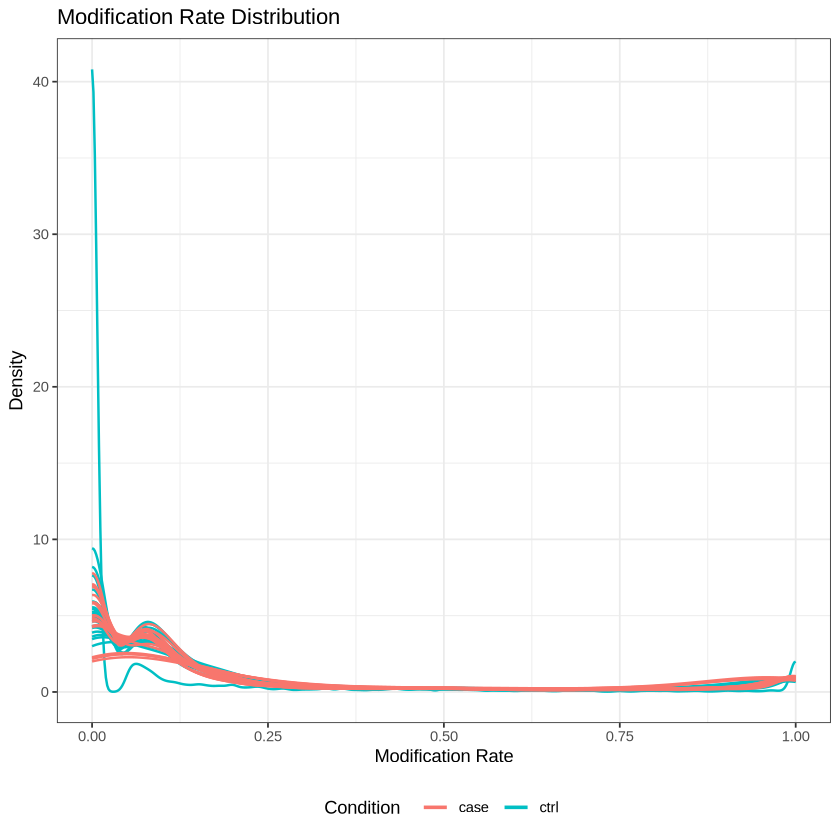

In [3]:
plot_mod_rate_distribution(m)

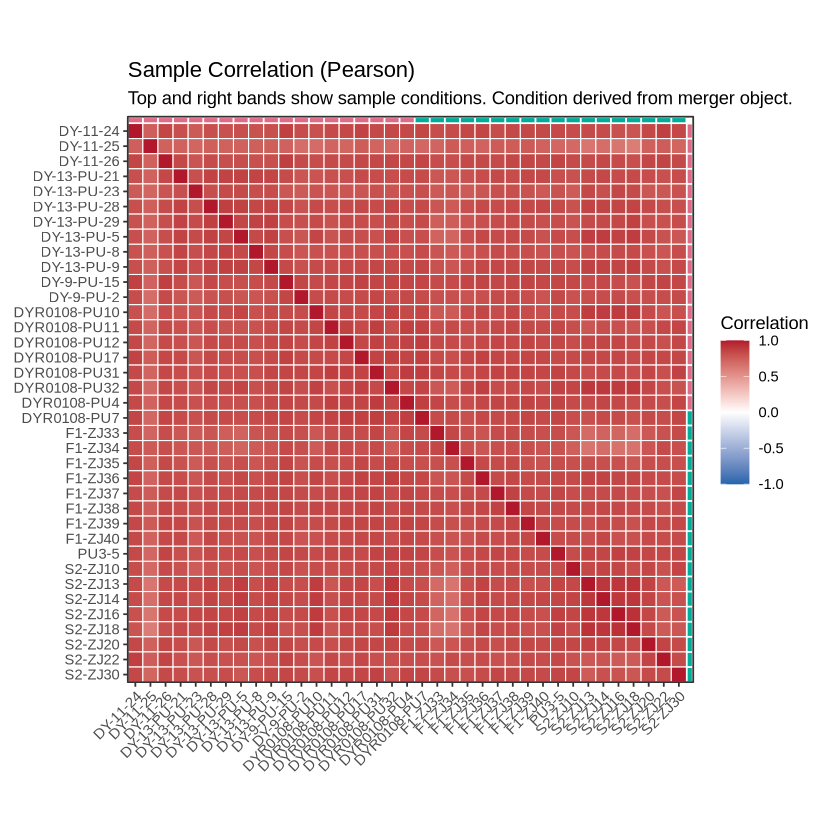

In [5]:
plot_sample_correlation(m)

In [ ]:
plot_merger_pca(m,impute_scope = "global")

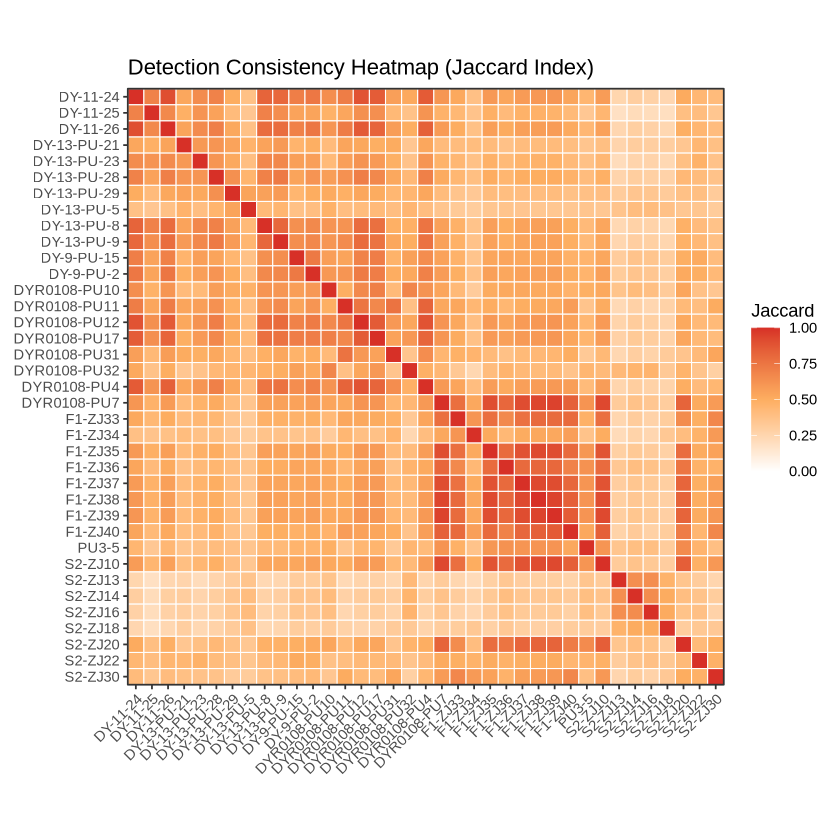

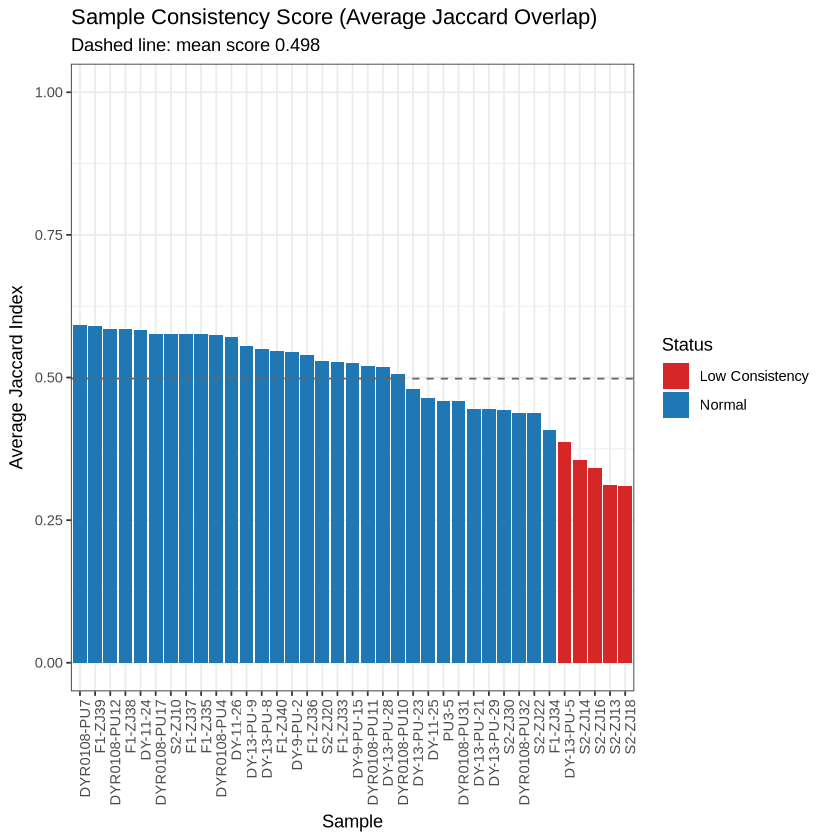

In [4]:
consistency <- plot_detection_consistency(m, show_score_bar = TRUE)


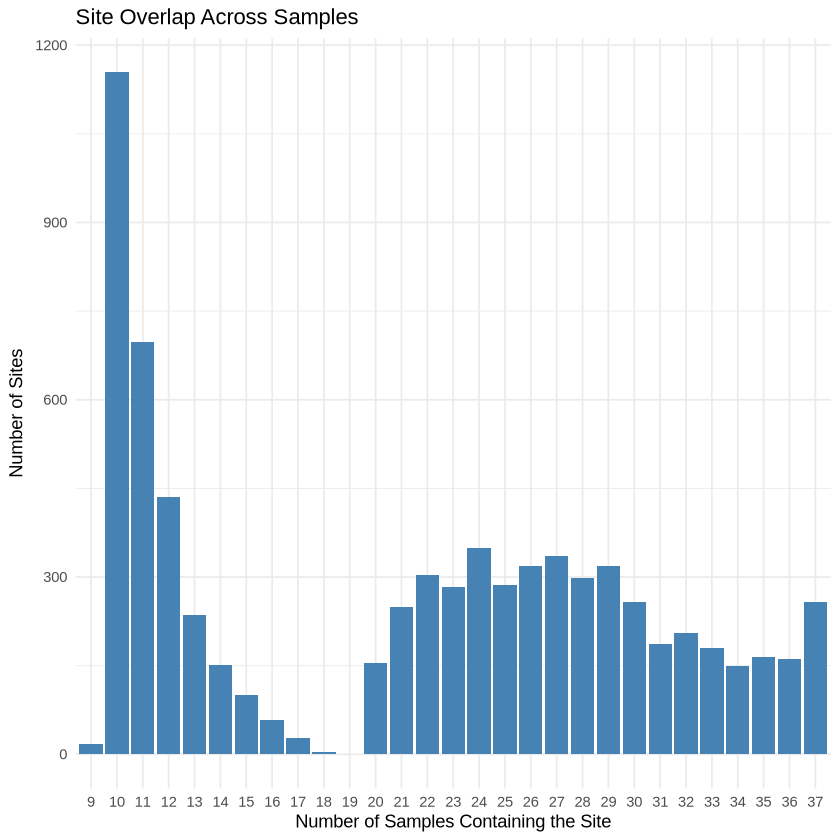

In [6]:
plot_site_overlap(m)

In [8]:
az <- new_saturation_analyzer(
  "/data_new/RNA_modi/puseq/BN0045/S2-ZJ16/alignment/genome/Aligned.sortedByCoord.out.dedup.bam",
  min_depth = 10L,
  min_mod_rate = 0.05,
  test_mode = FALSE
)
az$site_stats <- extract_site_stats(az)
run_saturation_analysis(
  az,
  random_seed = 42L,
  output_file = "/home/tangyh/script/Modsite/modsite.Rcheck/saturation_S2-ZJ16.png"
)

ratio,valid_sites
<dbl>,<int>
0.1,6515
0.2,10160
0.3,12922
0.4,14670
0.5,15790
0.6,16397
0.7,16879
0.8,17310
0.9,17591


In [2]:
base_dir <- "/data_new/RNA_modi/puseq/BN0045"

files <- list.files(
  path = base_dir,
  pattern = "^sncRNA\\.sites\\.tsv$",
  recursive = TRUE,
  full.names = TRUE
)

files <- normalizePath(files, winslash = "/", mustWork = FALSE)

sample_files <- files[!grepl("NC", files)]
conditions <- c("ctrl", "ctrl", "ctrl", "ctrl", "ctrl", "ctrl","ctrl", "ctrl", "ctrl", "ctrl", 
                "ctrl", "ctrl","ctrl", "ctrl", "ctrl", "ctrl", "ctrl", "ctrl","ctrl", "ctrl", 
                "case", "case", "case","case", "case", "case","case", "case", "case", "case",
                "case", "case", "case","case", "case", "case","case", "case", "case")


In [4]:
m <- new_merger(
  sample_files        = sample_files,
  condition           = conditions,
  modification_method = "PUMseq",
  min_modification_rate = 0.05,
  min_depth           = 10L,
  group_missing_threshold = 0.5,
  group_filter_strategy = "any"
)

In [5]:
merged_df <- merge_samples(m)

[1/39] Loading sample: DY-11-24

[2/39] Loading sample: DY-11-25

[3/39] Loading sample: DY-11-26

[4/39] Loading sample: DY-13-PU-21

[5/39] Loading sample: DY-13-PU-23

[6/39] Loading sample: DY-13-PU-27

[7/39] Loading sample: DY-13-PU-28

[8/39] Loading sample: DY-13-PU-29

[9/39] Loading sample: DY-13-PU-5

[10/39] Loading sample: DY-13-PU-8

[11/39] Loading sample: DY-13-PU-9

[12/39] Loading sample: DY-9-PU-15

[13/39] Loading sample: DY-9-PU-2

[14/39] Loading sample: DYR0108-PU10

[15/39] Loading sample: DYR0108-PU11

[16/39] Loading sample: DYR0108-PU12

[17/39] Loading sample: DYR0108-PU17

[18/39] Loading sample: DYR0108-PU31

[19/39] Loading sample: DYR0108-PU32

[20/39] Loading sample: DYR0108-PU4

[21/39] Loading sample: DYR0108-PU7

[22/39] Loading sample: F1-ZJ33

[23/39] Loading sample: F1-ZJ34

[24/39] Loading sample: F1-ZJ35

[25/39] Loading sample: F1-ZJ36

[26/39] Loading sample: F1-ZJ37

[27/39] Loading sample: F1-ZJ38

[28/39] Loading sample: F1-ZJ39

[29/39] Lo

In [13]:
annotate_snc_reference <- function(sites_df, gtf_file) {
  stopifnot(is.data.frame(sites_df))
  stopifnot(all(c("chrom", "pos") %in% colnames(sites_df)))
  gtf <- read.delim(
    gtf_file,
    sep = "\t",
    header = FALSE,
    quote = "",
    comment.char = "#",
    stringsAsFactors = FALSE
  )
  if (ncol(gtf) < 9) {
    stop("The GTF file must contain at least 9 columns.", call. = FALSE)
  }
  colnames(gtf)[1:9] <- c(
    "ref_name", "source", "feature", "ref_start", "ref_end",
    "score", "ref_strand", "phase", "attributes"
  )
  extract_attr <- function(x, key) {
    pat <- paste0(key, ' "([^"]*)"')
    m <- regexec(pat, x)
    out <- regmatches(x, m)
    vapply(
      out,
      function(z) if (length(z) >= 2) z[2] else NA_character_,
      character(1)
    )
  }
  ann_df <- data.frame(
    chrom      = gtf$ref_name,
    ref_start  = as.integer(gtf$ref_start),
    ref_end    = as.integer(gtf$ref_end),
    ref_strand = gtf$ref_strand,
    rna_type   = extract_attr(gtf$attributes, "type"),
    location   = extract_attr(gtf$attributes, "location"),
    gene_id    = extract_attr(gtf$attributes, "geneID"),
    gene_name  = extract_attr(gtf$attributes, "geneName"),
    product    = extract_attr(gtf$attributes, "product"),
    ncbi_id    = extract_attr(gtf$attributes, "ncbiID"),
    stringsAsFactors = FALSE
  )
  ann_df <- ann_df[!duplicated(ann_df$chrom), , drop = FALSE]
  idx <- match(sites_df$chrom, ann_df$chrom)
  out <- cbind(
    sites_df,
    ann_df[idx, c(
      "rna_type", "location", "gene_id", "gene_name",
      "product", "ncbi_id", "ref_start", "ref_end", "ref_strand"
    ), drop = FALSE]
  )
  out$in_ref_range <- with(
    out,
    !is.na(ref_start) & !is.na(ref_end) & pos >= ref_start & pos <= ref_end
  )
  out
}

In [14]:
merged_ann <- annotate_snc_reference(
  sites_df  = m$merged_data,
  gtf_file  = "/home/tangyh/reference/Homo_sapiens.GRCh38.sncRNA.gtf"
)

In [15]:
merged_ann

,chrom,pos,ref,strand,motif,DY-11-24,depth_DY-11-24,DY-11-25,depth_DY-11-25,DY-11-26,⋯,rna_type,location,gene_id,gene_name,product,ncbi_id,ref_start,ref_end,ref_strand,in_ref_range
,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<lgl>
753,premiRNA_MIR1248_40848,3,T,-,TTTAC,NA,47,NA,0,NA,⋯,premiRNA,NC_000003.12:186786672..186786777,100302143,MIR1248,microRNA,NR_031650.1,1,106,+,TRUE
748,premiRNA_MIR5588_40722,36,T,-,TTTAA,1.0000000,50,0.06976744,438,0.1111111,⋯,premiRNA,NC_000003.12:185253210..185253272,100847054,MIR5588,microRNA,NR_106712.1,1,63,-,TRUE
748.1,premiRNA_MIR5588_40722,39,T,-,AATGT,0.5000000,31,0.34615385,319,0.5000000,⋯,premiRNA,NC_000003.12:185253210..185253272,100847054,MIR5588,microRNA,NR_106712.1,1,63,-,TRUE
1710,premiRNA_MIR8086_90984,55,T,-,GATGG,0.0000000,57,1.00000000,224,0.0000000,⋯,premiRNA,NC_000010.11:28289258..28289350,102465880,MIR8086,microRNA,NR_107053.1,1,93,-,TRUE
1710.1,premiRNA_MIR8086_90984,71,T,-,GTTGC,0.0000000,46,0.00000000,127,NA,⋯,premiRNA,NC_000010.11:28289258..28289350,102465880,MIR8086,microRNA,NR_107053.1,1,93,-,TRUE
402,premiRNA_MIR8485_20050,49,T,-,CATAC,NA,0,NA,0,NA,⋯,premiRNA,NC_000002.12:50696172..50696262,103504737,MIR8485,microRNA,NR_130470.1,1,91,-,TRUE
1579,RNase-MRP-RNA_RMRP_83219,3,T,-,GGTTC,0.9723618,1985,1.00000000,640,0.9861111,⋯,RNase-MRP-RNA,NC_000009.12:35657751..35658018,6023,RMRP,RNA,NR_003051.3,1,268,-,TRUE
1579.1,RNase-MRP-RNA_RMRP_83219,4,T,-,GTTCG,NA,2102,NA,692,NA,⋯,RNase-MRP-RNA,NC_000009.12:35657751..35658018,6023,RMRP,RNA,NR_003051.3,1,268,-,TRUE
1579.2,RNase-MRP-RNA_RMRP_83219,22,T,-,TATCC,NA,0,NA,0,NA,⋯,RNase-MRP-RNA,NC_000009.12:35657751..35658018,6023,RMRP,RNA,NR_003051.3,1,268,-,TRUE


In [17]:
devtools::load_all("/home/tangyh/script/Modsite")
library(GenomicRanges)
library(IRanges)
# 1. 读入你保存的 GLMM 结果
glmm_df <- read.csv(
  "/home/tangyh/script/Modsite/modsite.Rcheck/glm.csv",
  stringsAsFactors = FALSE
)


ℹ Loading modsite


In [20]:
glmm_small

,X,site_id,chrom,pos,ref,strand,motif,group_est_logodds,group_or,group_p.value,group_adj_p.value,fit_ok,error_msg,primary_match_error,or_extreme
,<int>,<chr>,<chr>,<int>,<lgl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>
1,1,1_632693_T_-,1,632693,TRUE,-,GATAT,-1.502522184,0.2225681,0.11381497,0.9999844,TRUE,NA,NA,FALSE
2,2,1_632695_T_-,1,632695,TRUE,-,TATTA,0.914902635,2.4965322,0.30463268,0.9999844,TRUE,NA,NA,FALSE
3,3,1_632696_T_-,1,632696,TRUE,-,ATTAG,1.419657815,4.1357050,0.14083125,0.9999844,TRUE,NA,NA,FALSE
4,4,1_9728616_T_-,1,9728616,TRUE,-,GTTCC,0.370043301,1.4477973,0.46601499,0.9999844,TRUE,NA,NA,FALSE
5,5,1_10316929_T_+,1,10316929,TRUE,+,GATGG,0.629400220,1.8764848,0.53861450,0.9999844,TRUE,NA,NA,FALSE
6,6,1_10316937_T_+,1,10316937,TRUE,+,CTTGC,0.019683275,1.0198783,0.95849092,0.9999844,TRUE,NA,NA,FALSE
7,7,1_10316975_T_+,1,10316975,TRUE,+,CCTGA,0.143949609,1.1548259,0.83640014,0.9999844,TRUE,NA,NA,FALSE
8,8,1_11908162_T_-,1,11908162,TRUE,-,GTTTC,-0.012574078,0.9875046,0.94043564,0.9999844,TRUE,NA,NA,FALSE
9,9,1_11908173_T_-,1,11908173,TRUE,-,AATCG,0.558094560,1.7473399,0.27049095,0.9999844,TRUE,NA,NA,FALSE


In [22]:
annotator <- new_genomic_annotator(
  gtf_file = "/home/tangyh/reference/Homo_sapiens.GRCh38.113.gtf"
)

Loading GTF and building TxDb: Homo_sapiens.GRCh38.113.gtf

Import genomic features from the file as a GRanges object ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
Warning message in .get_cds_IDX(mcols0$type, mcols0$phase):
“The "phase" metadata column contains non-NA values for features of type
  stop_codon. This information was ignored.”
OK

Importing GTF for gene metadata ...

Pre-extracting transcript features ...

Building transcript-to-gene mapping ...

'select()' returned 1:1 mapping between keys and columns

Annotator ready in 193.4 s.



In [ ]:
# 2. 只取前 20 个位点做最小测试
glmm_df <- glmm_df[1:20, ]
# 3. 看一下染色体命名风格
glmm_df$chrom <- as.character(glmm_df$chrom)
if ("strand" %in% names(glmm_df)) {
  glmm_df$strand <- as.character(glmm_df$strand)
}
mg <- new_metagene_analyzer(
  annotator = annotator,
  sites_df = glmm_df,
  n_bins = 20
)
mg <- calc_grouped_metagene_profile(
  mg,
  group_by = "motif",
  stat = "density",
  filter = ~ fit_ok & !or_extreme
)
plot_metagene_groups(mg)

Initialising MetageneAnalyzer: 20 sites, 20 bins, strategy = median

Mapping sites to transcript coordinates...

